In [1]:
import yaml
import os

yaml_path = "../resources/scadsai.yml"

with open(yaml_path, "r", encoding="utf-8") as yml_file:
    data = yaml.safe_load(yml_file)

urls = []
records = data["resources"]

In [2]:
records[0]

{'authors': ['Lea Kabjesz',
  'Lea Gihlein',
  'Mara Harriet Lampert',
  'Robert Haase'],
 'description': 'This record contains the poster "Smart Slide Generation: Re-Using Training Materials Through the Power of LLMs" presented by Lea Kabjesz and Lea Gihlein at the All Hands Meeting of the German AI Centers, held on 5th - 6th November 2025 at DFKI Saarbr&uuml;cken, Germany.&nbsp;\n&nbsp;\nWe acknowledge funding by the Deutsche Forschungsgemeinschaft (DFG, German Research Foundation) under the National Research Data Infrastructure &ndash; NFDI 46/1 &ndash; 501864659.',
 'license': 'CC-BY-4.0',
 'name': 'Smart Slide Generation: Re-Using Training Materials Through the Power of LLMs',
 'num_downloads': 94,
 'publication_date': '2025-11-06',
 'submission_date': '2025-11-12T10:40:41.173228',
 'tags': ['Research Data Management', 'Training Materials'],
 'url': ['https://zenodo.org/records/17541532',
  'https://doi.org/10.5281/zenodo.17541532']}

In [3]:
import pandas as pd

def get_record_type(url):
    url_str = str(url)
    if "https://huggingface.co/" in url_str:
        return "huggingface"
    elif "zenodo" in url_str:
        return "zenodo"
    elif "github" in url_str:
        return "github"
    else:
        return "other"

df = pd.DataFrame(records)
df["record-type"] = df["url"].apply(get_record_type)

df.head()

,authors,description,license,name,num_downloads,publication_date,submission_date,tags,url,type,record-type
0,"[Lea Kabjesz, Lea Gihlein, Mara Harriet Lamper...","This record contains the poster ""Smart Slide G...",CC-BY-4.0,Smart Slide Generation: Re-Using Training Mate...,94.0,2025-11-06,2025-11-12T10:40:41.173228,"[Research Data Management, Training Materials]","[https://zenodo.org/records/17541532, https://...",NaN,zenodo
1,[Robert Haase],"This dataset contains author names, titles and...",CC-ZERO,Selected meta data of accepted contributions t...,6.0,2025-10-29,2025-11-12T10:40:41.894482,[Dataset],"[https://zenodo.org/records/17478160, https://...",NaN,zenodo
2,[Robert Haase],"In this Lunch Lecture at Leipzig University, w...",CC-BY-4.0,How Generative AI impacts research and teaching,157.0,2025-10-23,2025-11-12T10:40:43.301368,[Training Materials],"[https://zenodo.org/records/17422917, https://...",NaN,zenodo
3,[Josefine Umlauft],This dataset contains seismic and meteorologic...,CC-BY-4.0,TreeSway,42.0,2025-10-01,2025-11-12T10:40:46.003266,[Dataset],"[https://zenodo.org/records/17240205, https://...",NaN,zenodo
4,[Robert Haase],Dieses Slide-Deck is begleitend zum KI-Kompete...,CC-BY-4.0,AI4Psychology KI-Kompetenz-Training,176.0,2025-09-25,2025-11-12T10:40:46.558131,[Training Materials],"[https://zenodo.org/records/17203260, https://...",NaN,zenodo


In [4]:
import matplotlib.pyplot as plt

In [5]:
# Prepare data
df["publication_date"] = pd.to_datetime(df["publication_date"], format='mixed', utc=True)

df["year_month"] = df["publication_date"].dt.to_period("M")

C:\Users\haase\AppData\Local\Temp\ipykernel_34176\1436764487.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["publication_date"].dt.to_period("M")


In [6]:
# Group and pivot
summary = df.groupby(["year_month", "record-type"]).size().unstack(fill_value=0)
summary = summary.sort_index()

In [7]:
summary.index

PeriodIndex(['2016-04', '2017-10', '2018-11', '2019-04', '2019-07', '2019-10',
             '2020-02', '2020-04', '2020-06', '2020-08', '2020-09', '2020-10',
             '2021-01', '2021-02', '2021-03', '2021-05', '2021-07', '2021-08',
             '2021-09', '2021-10', '2021-12', '2022-01', '2022-03', '2022-04',
             '2022-06', '2022-07', '2022-08', '2022-09', '2022-12', '2023-01',
             '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07',
             '2023-08', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02',
             '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08',
             '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02',
             '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08',
             '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02',
             '2026-03', '2026-04', '2026-05', '2026-06', '2026-07', '2026-08'],
            dtype='period[M]', name='year_month')

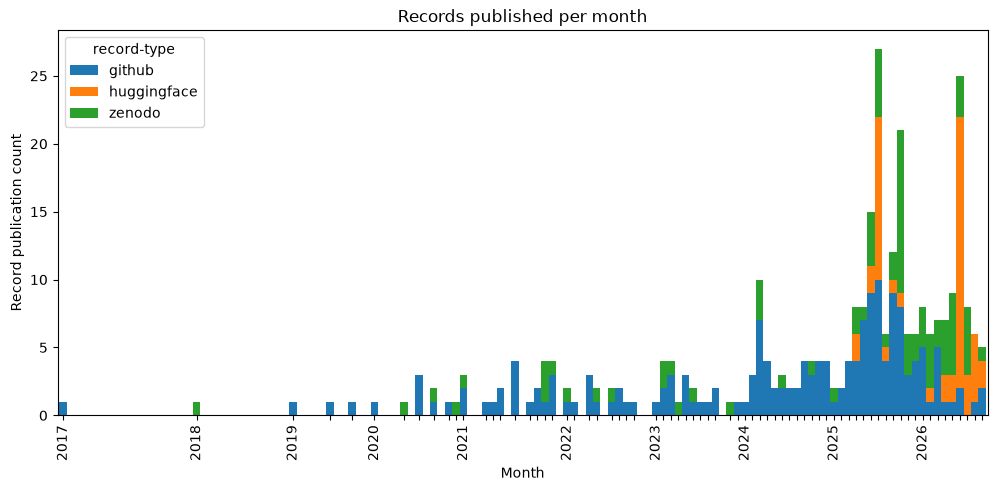

In [12]:
# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 5))
summary.plot(kind="bar", stacked=True, ax=ax, width=1.0)
tick_labels = [d.strftime("%Y") if d.year != d_.year else "" for d, d_ in zip(summary.index[1:], summary.index)]+ [""]
ax.set_xticklabels(tick_labels)

ax.set_xlabel("Month")
ax.set_ylabel("Record publication count")
ax.set_title("Records published per month")

plt.show()

In [9]:
oldest_per_type = df.sort_values("publication_date").groupby("record-type").first().reset_index()
print(oldest_per_type)

   record-type                                            authors  \
0       github  [Kevin Shrestha, Hans Pogrzeba, Christopher Ro...   
1  huggingface                                      [Lea Gihlein]   
2       zenodo  [Johannes Kiesel, Martin Potthast, Matthias Ha...   

                                         description       license  \
0                      A free Open Source Tweet Map     APACHE-2.0   
1  \n\t\n\t\t\n\t\n\t\n\t\tAbout this Dataset\n\t...     cc-by-4.0   
2  The Webis-Web-Archive-17 comprises a total of ...  CC-BY-SA-4.0   

                   name  num_downloads          publication_date  \
0                OSTMap            NaN 2016-04-22 12:16:16+00:00   
1    SlideInsight_Cache           14.0 2025-03-07 00:00:00+00:00   
2  Webis-Web-Archive-17       820405.0 2017-10-04 00:00:00+00:00   

              submission_date  \
0  2025-11-12T11:18:59.765105   
1  2026-07-09T22:44:23.008242   
2  2025-12-14T09:31:58.970005   

                                    

In [10]:
for i in oldest_per_type["url"]:
    print(i)

https://github.com/ScaDS/OSTMap
https://huggingface.co/datasets/ScaDSAI/SlideInsight_Cache
['https://zenodo.org/records/4064019', 'https://doi.org/10.5281/zenodo.4064019']
